## Модель кредитного скоринга для прогнозирования дефолтов

### Загрузка данных

In [2]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('cs-training.csv').drop(columns=['Unnamed: 0'])

- **target**: Дефолт (просрочка 90+ дней в течение 2 лет)
- **delq_30_59**: Кол-во просрочек 30-59 дней (последние 2 года)
- **delq_60_89**: Кол-во просрочек 60-89 дней (последние 2 года)
- **delq_90_plus**: Кол-во просрочек 90+ дней (вся история, кроме периода таргета)
- **credit_util**: Утилизация кредитных карт (0-1 или >1 если большие долги)
- **credit_cards**: Всего открытых кредитных линий/карт
- **estate_cnt**: Кол-во ипотек / кредитов под залог недвижимости
- **age**: Возраст заемщика (в годах)
- **monthly_salary**: Ежемесячный доход (доллар США)
- **debt_ratio**: Долговая нагрузка (ежемес.платежи / доход)
- **dependents_cnt**: Кол-во иждивенцев

In [4]:
rename_dict = {
    'SeriousDlqin2yrs': 'target',

    'NumberOfTime30-59DaysPastDueNotWorse': 'delq_30_59',
    'NumberOfTime60-89DaysPastDueNotWorse': 'delq_60_89',
    'NumberOfTimes90DaysLate': 'delq_90_plus',
    
    'RevolvingUtilizationOfUnsecuredLines': 'credit_util',
    'NumberOfOpenCreditLinesAndLoans': 'credit_cards',
    'NumberRealEstateLoansOrLines': 'estate_cnt',
    
    'age': 'age',
    'MonthlyIncome': 'monthly_salary',
    'DebtRatio': 'debt_ratio',
    
    'NumberOfDependents': 'dependents_cnt'
}

data = data.rename(columns=rename_dict)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   target          150000 non-null  int64  
 1   credit_util     150000 non-null  float64
 2   age             150000 non-null  int64  
 3   delq_30_59      150000 non-null  int64  
 4   debt_ratio      150000 non-null  float64
 5   monthly_salary  120269 non-null  float64
 6   credit_cards    150000 non-null  int64  
 7   delq_90_plus    150000 non-null  int64  
 8   estate_cnt      150000 non-null  int64  
 9   delq_60_89      150000 non-null  int64  
 10  dependents_cnt  146076 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 12.6 MB


### Обработка пропусков

Начнем с обработки пропусков, они присутствуют в переменных **monthly_salary** и **dependents_cnt**. Посмотрим на их распределения

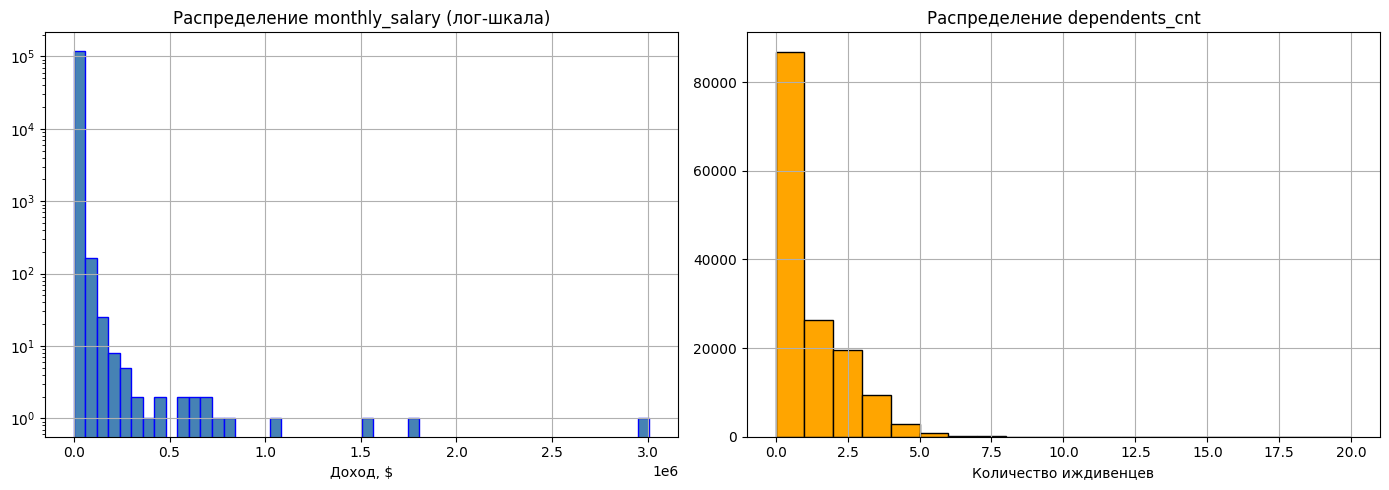

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма monthly_salary
data['monthly_salary'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='blue')
axes[0].set_title('Распределение monthly_salary (лог-шкала)', fontsize=12)
axes[0].set_yscale('log')
axes[0].set_xlabel('Доход, $')

data['dependents_cnt'].hist(bins=20, ax=axes[1], color='orange', edgecolor='black')
axes[1].set_title('Распределение dependents_cnt', fontsize=12)
axes[1].set_xlabel('Количество иждивенцев')

plt.tight_layout()

plt.show()


Посмотрим как связаны пропуски в этих переменных с таргетом

In [7]:
data['salary_missing_flag'] = data['monthly_salary'].isnull().astype(int)
salary_default_rate = data.groupby('salary_missing_flag')['target'].mean()
print(f"Есть данные о доходе: {salary_default_rate[0]:.4f} default rate")
print(f"Пропущен доход:     {salary_default_rate[1]:.4f} default rate")
print(f"Разница:            {salary_default_rate[1] - salary_default_rate[0]:+.4f}\n")

Есть данные о доходе: 0.0695 default rate
Пропущен доход:     0.0561 default rate
Разница:            -0.0133



In [8]:
data['dependents_missing_flag'] = data['dependents_cnt'].isnull().astype(int)
dependents_default_rate = data.groupby('dependents_missing_flag')['target'].mean()
print(f"Есть данные об иждивенцах: {dependents_default_rate[0]:.4f} default rate")
print(f"Пропущены иждивенцы:      {dependents_default_rate[1]:.4f} default rate")
print(f"Разница:                  {dependents_default_rate[1] - dependents_default_rate[0]:+.4f}")

Есть данные об иждивенцах: 0.0674 default rate
Пропущены иждивенцы:      0.0456 default rate
Разница:                  -0.0218


Видим, что те, кто не указал доход или иждивенцев, реже просрочивали платежи по кредиту. Возможно, те кто не указывает доходы, скрывает их, и можно сделать вывод, что такие люди более обеспеченные. Те, кто не указал иждивенцев, скорее всего их и не имеют, значит холостяки. У них меньше финансовая нагрузка, поэтому они лучше выплачивают кредиты

Тогда мы оставим информацию о тех, кто не указывал зарплату в отдельной переменной, пропуски заменим медианой. А пропуски в иждивенцах заполним нулями

In [9]:
# Рассчитываем групповую медиану по возрасту и кол-ву кредиток, чтобы сохранить распределение

data['age_group'] = (data['age'] // 10) * 10
data['cards_group'] = pd.cut(data['credit_cards'], bins=[0, 2, 5, 100], labels=['1-2', '3-5', '6+'])

group_medians = data.groupby(['age_group', 'cards_group'], observed=True)['monthly_salary'].median().reset_index()
group_medians.columns = ['age_group', 'cards_group', 'salary_group_median']

data = data.merge(group_medians, on=['age_group', 'cards_group'], how='left')

# На всякий случай, если будут пропуски, рассчитываем медиану по возрасту

age_medians = data.groupby('age_group')['monthly_salary'].median().reset_index()
age_medians.columns = ['age_group', 'salary_age_median']

data = data.merge(age_medians, on='age_group', how='left')

# Заполняем пропуски по уровням

data['monthly_salary'] = data['monthly_salary'].fillna(data['salary_group_median'])
data['monthly_salary'] = data['monthly_salary'].fillna(data['salary_age_median'])
data['monthly_salary'] = data['monthly_salary'].fillna(data['monthly_salary'].median())

# Пропуски иждивенцев

data['dependents_cnt'] = data['dependents_cnt'].fillna(0)

data = data.drop(columns=['salary_group_median', 'salary_age_median', 'age_group', 'cards_group'])

### Обработка выбросов

Пропуски заполнили, теперь перейдем к работе с выбросами. Просто так их удалить будет некорректно, поэтому будем анализировать

In [10]:
cols = [c for c in data.columns.tolist() if c != 'target']

stats = data[cols].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T
stats['iq_ratio'] = stats['99%'] / (stats['mean'] + 1)  # отношение 99-го перцентиля к среднему
print(stats[['min', 'mean', 'max', '99%', 'iq_ratio']].round(2))

                         min     mean        max       99%  iq_ratio
credit_util              0.0     6.05    50708.0      1.09      0.16
age                      0.0    52.30      109.0     87.00      1.63
delq_30_59               0.0     0.42       98.0      4.00      2.81
debt_ratio               0.0   353.01   329664.0   4979.04     14.06
monthly_salary           0.0  6394.39  3008750.0  23000.00      3.60
credit_cards             0.0     8.45       58.0     24.00      2.54
delq_90_plus             0.0     0.27       98.0      3.00      2.37
estate_cnt               0.0     1.02       54.0      4.00      1.98
delq_60_89               0.0     0.24       98.0      2.00      1.61
dependents_cnt           0.0     0.74       20.0      4.00      2.30
salary_missing_flag      0.0     0.20        1.0      1.00      0.83
dependents_missing_flag  0.0     0.03        1.0      1.00      0.97


Разберемся по всем столбцам. **credit_cards**, **estate_cnt**, **dependents_cnt** в целом достаточно корректные, можно немного исправить.  
  
Столбцы **delq_30_59**, **delq_60_89**, **delq_90_plus** имеют значение 98, скорее всего это не баг, а какой-то хронический нарушитель. Можно убрать выбросы по 99 перцентилю, и сделать флаг для всех значений, которые больше него;   
  
**credit_util** содержит ошибку данных;  
  
в столбце **age** стоит убрать нулевой возраст, обрезать с 18 по 85;   
  
**monthly_salary** содержит огромное значение, поэтому его стоит также обрезать по 99 перцентилю  
  
**debt_ratio** самый плохой столбец. В нем рассчитывается отношение ежемесячных платежей к зарплате, и при зарплате 0 он может быть огромным. Среднее 353, хотя должно быть < 1. Стоит заменить нулевые зарплаты и пересчитать это значение, для остальных обрезать по 99 перцентилю, и также можно создать флаг для значений, которые больше него

In [11]:
# Обрезаем возраст

data = data[(data['age'] >= 18) & (data['age'] <= 85)]

# Заменяем нулевые зарплаты

data['salary_was_zero'] = (data['monthly_salary'] == 0).astype(int)
median = data.loc[data['salary_missing_flag'] == 0, 'monthly_salary'].median()
data.loc[data['monthly_salary'] == 0, 'monthly_salary'] = median

data['monthly_salary'] = data['monthly_salary'].clip(upper=data['monthly_salary'].quantile(0.99))

# Работаем с debt_ratio

debt_quant = data['debt_ratio'].quantile(0.99)
data['debt_ratio_extreme'] = (data['debt_ratio'] > debt_quant).astype(int)
data['debt_ratio'] = data['debt_ratio'].clip(upper=debt_quant)

# credit_util

data['credit_util_extreme'] = (data['credit_util'] > 1.0).astype(int)
util_quant = data['credit_util'].quantile(0.99)
data['credit_util'] = data['credit_util'].clip(upper=util_quant)

# Просрочки

cols = ['delq_30_59', 'delq_60_89', 'delq_90_plus']
delq_quants = {}
for col in cols:
    delq_quants[col] = data[col].quantile(0.99)

data['delq_extreme'] = (
    (data['delq_30_59'] > delq_quants['delq_30_59']) |
    (data['delq_60_89'] > delq_quants['delq_60_89']) |
    (data['delq_90_plus'] > delq_quants['delq_90_plus'])
).astype(int)

for col in cols:
    data[col] = data[col].clip(upper=delq_quants[col])

# Винзоризация остальных данных

for col in ['credit_cards', 'estate_cnt', 'dependents_cnt']:
    quant = data[col].quantile(0.995)
    if (data[col] > quant).sum() > 0:
        data[col] = data[col].clip(upper=quant)

In [12]:
cols = [c for c in data.columns.tolist() if c != 'target']

stats = data[cols].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T
stats['iq_ratio'] = stats['99%'] / (stats['mean'] + 1)  # отношение 99-го перцентиля к среднему
print(stats[['min', 'mean', 'max', '99%', 'iq_ratio']].round(2))

                          min     mean       max       99%  iq_ratio
credit_util               0.0     0.32      1.10      1.10      0.83
age                      21.0    51.79     85.00     82.00      1.55
delq_30_59                0.0     0.25      4.00      4.00      3.21
debt_ratio                0.0   319.55   4996.84   4996.35     15.59
monthly_salary            1.0  6200.56  23184.34  23177.76      3.74
credit_cards              0.0     8.46     27.00     24.00      2.54
delq_90_plus              0.0     0.09      3.00      3.00      2.76
estate_cnt                0.0     1.02      6.00      4.42      2.19
delq_60_89                0.0     0.06      2.00      2.00      1.88
dependents_cnt            0.0     0.74      5.00      4.00      2.29
salary_missing_flag       0.0     0.20      1.00      1.00      0.84
dependents_missing_flag   0.0     0.02      1.00      1.00      0.98
salary_was_zero           0.0     0.01      1.00      1.00      0.99
debt_ratio_extreme        0.0     

Теперь везде у нас корерктные значения, нет каких-то аномалий, а также мы зафиксировали в отдельных переменных экстремальные значения

### Feature Engineering (создание новых признаков)

Приступим к созданию новых признаков

In [13]:
# Доход на одного члена семьи
data['salary_per_person'] = data['monthly_salary'] / (data['dependents_cnt'] + 1)

# Платежная нагрузка
data['monthly_debt'] = data['debt_ratio'] * data['monthly_salary']

# Остаток денег после выплат
data['money_left'] = data['monthly_salary'] - data['monthly_debt']

# Общее количество просрочек
data['delq_total'] = data['delq_30_59'] + data['delq_60_89'] + data['delq_90_plus']

# Взвешенная сума просрочек
data['delq_weighted_score'] = (
    data['delq_30_59'] * 1 +
    data['delq_60_89'] * 3 +
    data['delq_90_plus'] * 10
)

# Были ли просрочки вообще
data['delq_ever_30'] = (data['delq_30_59'] > 0).astype(int)
data['delq_ever_60'] = (data['delq_60_89'] > 0).astype(int)
data['delq_ever_90'] = (data['delq_90_plus'] > 0).astype(int)

# Соотношение кредитных карт к ипотекам
data['credit_estate'] = data['credit_cards'] / (data['estate_cnt'] + 1)

# Метрика риска, долги * просрочки
data['risk_debt'] = data['credit_util'] * data['delq_weighted_score']

# Финансовый стресс
median = data['monthly_salary'].median()
data['risk_financial_stress'] = (
    (data['debt_ratio'] > 0.4) & 
    (data['monthly_salary'] < median)
).astype(int)

# Идеальный заемщик
data['risk_prime_client'] = (
    (data['delq_total'] == 0) &
    (data['credit_util'] < 0.3) &
    (data['debt_ratio'] < 0.3) &
    (data['monthly_salary'] > median)
).astype(int)

Посмотрим корреляцию для новых признаков

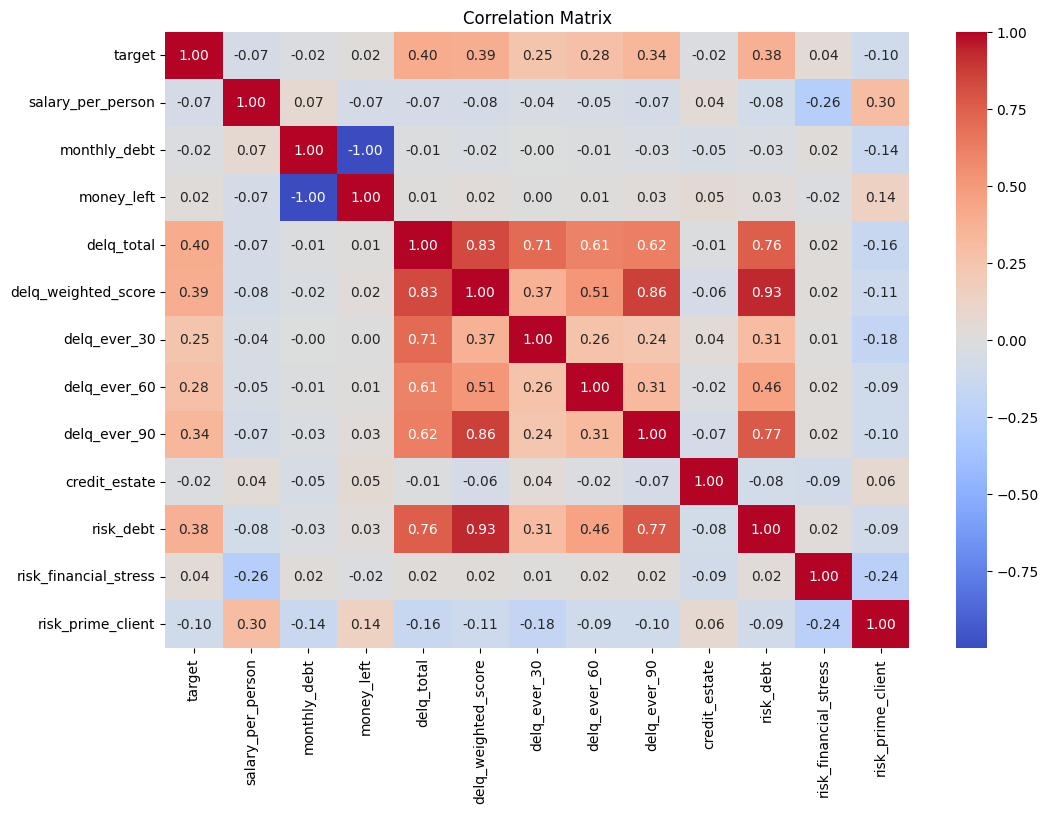

In [14]:
cols = [
    'target', 'salary_per_person', 'monthly_debt', 'money_left', 'delq_total', 
    'delq_weighted_score', 'delq_ever_30', 'delq_ever_60', 'delq_ever_90',
    'credit_estate', 'risk_debt', 'risk_financial_stress', 'risk_prime_client'
]
plt.figure(figsize=(12,8))
sns.heatmap(data[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Признаки **risk_financial_stress**, **money_left**, **credit_estate** и **monthly_debt** дают слабую корреляцию, поэтому уберем их

In [15]:
data = data.drop(columns=['risk_financial_stress', 'money_left', 'credit_estate', 'monthly_debt'])

Также посмотрим корреляцию для старых признаков

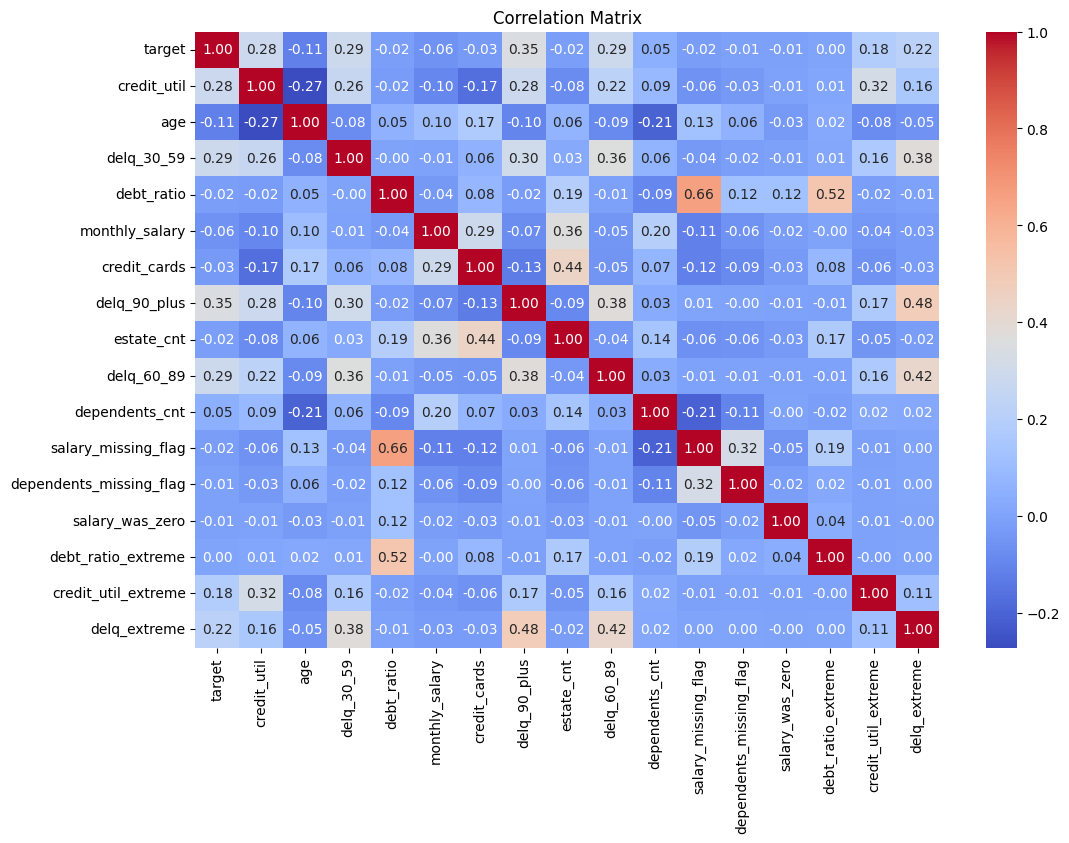

In [16]:
cols = [
    'target', 'credit_util', 'age', 'delq_30_59', 'debt_ratio',
    'monthly_salary', 'credit_cards', 'delq_90_plus', 'estate_cnt',
    'delq_60_89', 'dependents_cnt', 'salary_missing_flag',
    'dependents_missing_flag', 'salary_was_zero', 'debt_ratio_extreme',
    'credit_util_extreme', 'delq_extreme'
]

plt.figure(figsize=(12,8))
sns.heatmap(data[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Можно удалить **debt_ratio_extreme**, потому что корреляция равна 0

In [17]:
data = data.drop(columns=['debt_ratio_extreme'])

### Создание модели (CatBoost)

Теперь можем приступить к обучению модели

In [18]:
from sklearn.model_selection import train_test_split

y = data['target']
X = data.drop(columns=['target'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Для начала обучим логистическую регрессию, и будем от нее отталкиваться

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score, roc_curve
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train_scaled, y_train)

y_pred_lr = model.predict(X_test_scaled)
y_proba_lr = model.predict_proba(X_test_scaled)[:, 1]

print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_lr):.4f}")

ROC-AUC:  0.8614
Precision: 0.2143
Recall:    0.7560
F1-score:  0.3340


Теперь обучим CatBoost

In [20]:
from catboost import CatBoostClassifier

cb_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    subsample=0.8,
    random_seed=42,
    verbose=100,
    thread_count=-1
)

cb_model.fit(X_train, y_train)

y_pred_cb = cb_model.predict(X_test)
y_proba_cb = cb_model.predict_proba(X_test)[:, 1]

print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_cb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_cb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_cb):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_cb):.4f}")

0:	learn: 0.6238174	total: 70.3ms	remaining: 35.1s
100:	learn: 0.1771487	total: 1.17s	remaining: 4.6s
200:	learn: 0.1739177	total: 2.2s	remaining: 3.27s
300:	learn: 0.1714662	total: 3.18s	remaining: 2.1s
400:	learn: 0.1692559	total: 4.11s	remaining: 1.01s
499:	learn: 0.1671909	total: 5.04s	remaining: 0us
ROC-AUC:  0.8689
Precision: 0.6027
Recall:    0.1794
F1-score:  0.2764


### Оценка калибровки вероятностей

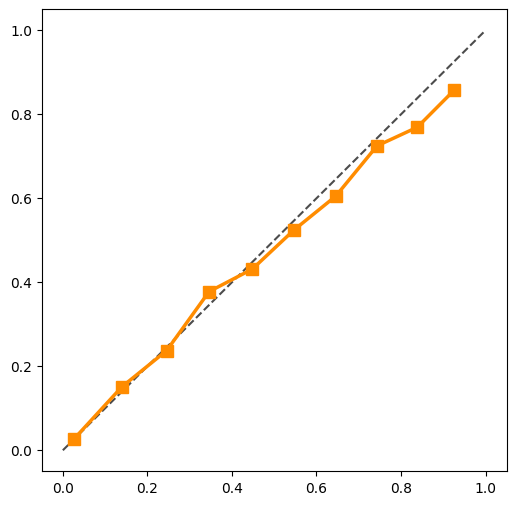

In [23]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

prob_true, prob_pred = calibration_curve(
    y_test, 
    y_proba_cb, 
    n_bins=10,
    strategy='uniform'
)

plt.figure(figsize=(6, 6))

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Идеальная калибровка', alpha=0.7)

plt.plot(prob_pred, prob_true, 's-', color='darkorange', lw=2.5, markersize=8, 
         label='CatBoost (до калибровки)')
plt.show()

### Подбор порога под бизнес-задачу

Находим порог, который принесет больше всего прибыли

In [24]:
from sklearn.metrics import confusion_matrix

profit_per_good = 20_000
loss_per_bad = 80_000

best_profit = -np.inf
best_threshold_profit = 0
results_profit = []

# Перебираем пороги
for t in np.linspace(0.01, 0.99, 100):
    y_pred = (y_proba_cb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    earned = tn * profit_per_good
    lost = fn * loss_per_bad
    net = earned - lost
    
    results_profit.append({
        'threshold': t,
        'net_profit': net,
        'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'approval_rate': (y_proba_cb <= t).mean(),
        'tp': tp, 'fn': fn, 'fp': fp, 'tn': tn
    })
    
    if net > best_profit:
        best_profit = net
        best_threshold_profit = t

results_profit.sort(key=lambda x: x['net_profit'], reverse=True)

print("Топ-5 порогов по чистой прибыли:")
print(f"{'Порог':<10} {'Прибыль':<15} {'Precision':<12} {'Recall':<10} {'Одобрение':<10} {'Поймано':<10} {'Пропущено'}")
print("-" * 80)
for r in results_profit[:5]:
    print(f"{r['threshold']:<10.4f} {r['net_profit']:>13,.0f} ₽  "
          f"{r['precision']:.4f}       {r['recall']:.4f}     "
          f"{r['approval_rate']:.1%}        {r['tp']:<8}  {r['fn']}")

Топ-5 порогов по чистой прибыли:
Порог      Прибыль         Precision    Recall     Одобрение  Поймано    Пропущено
--------------------------------------------------------------------------------
0.1585       441,540,000 ₽  0.3517       0.5726     89.0%        1143      853
0.1684       441,520,000 ₽  0.3602       0.5551     89.6%        1108      888
0.2476       441,380,000 ₽  0.4348       0.4559     92.9%        910       1086
0.2179       441,320,000 ₽  0.4048       0.4860     91.9%        970       1026
0.1783       441,200,000 ₽  0.3676       0.5381     90.1%        1074      922


### SHAP-анализ

In [25]:
import shap

explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_test)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Построим графики SHAP, которые помогут визуализировать важность признаков при принятии решений

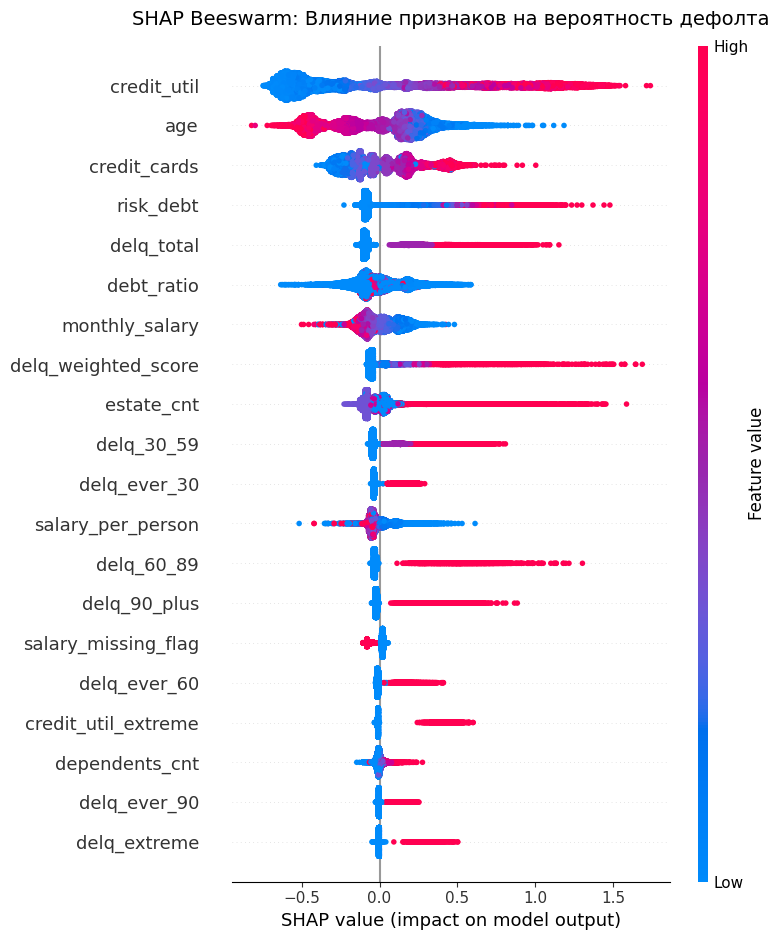

In [28]:
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title('SHAP Beeswarm: Влияние признаков на вероятность дефолта', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

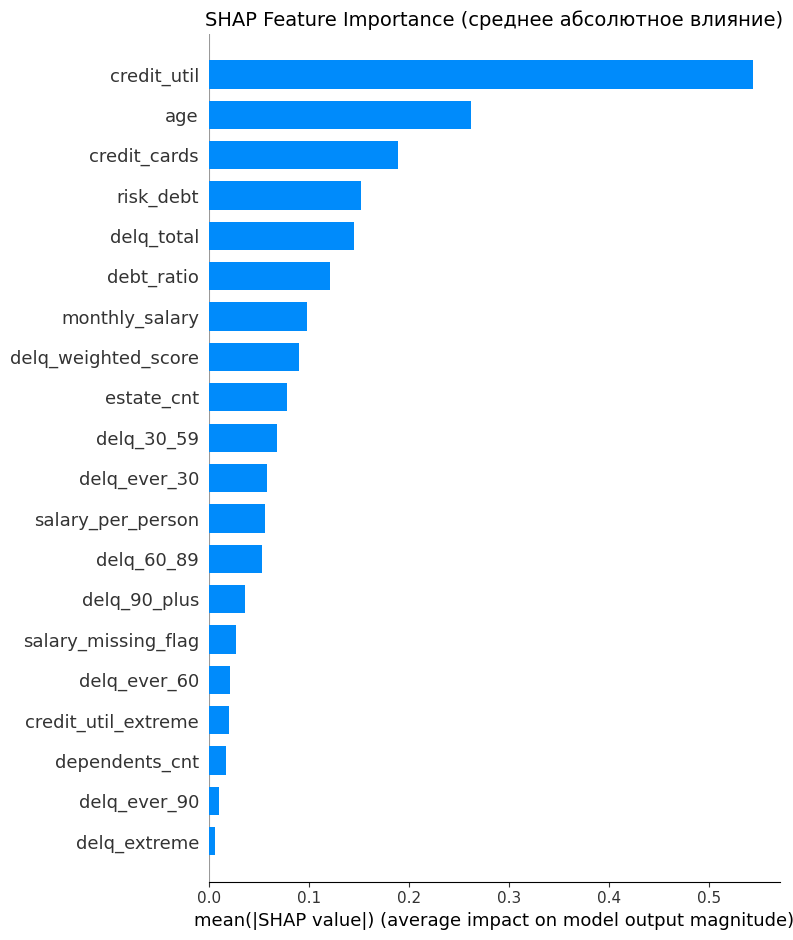

In [29]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (среднее абсолютное влияние)', fontsize=14)
plt.tight_layout()
plt.show()

Клиент #115
Реальный класс: дефолт
Предсказанная вероятность дефолта: 0.4578
Средняя вероятность дефолта (base value): 0.0675


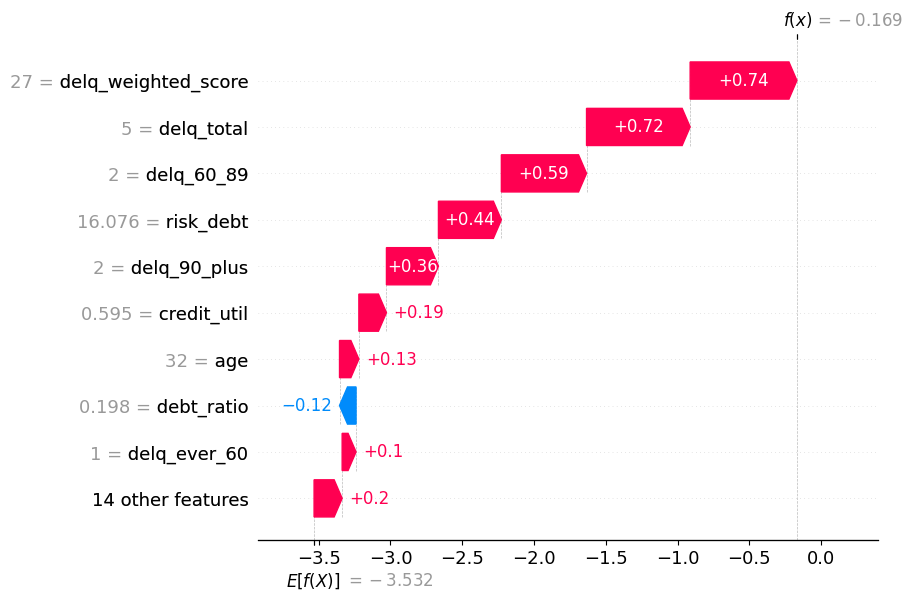

In [30]:
# Берём первого дефолтника из теста
default_indices = np.where(y_test == 1)[0]
client_idx = default_indices[5]

print(f"Клиент #{client_idx}")
print(f"Реальный класс: {'дефолт' if y_test.iloc[client_idx] == 1 else 'хороший'}")
print(f"Предсказанная вероятность дефолта: {y_proba_cb[client_idx]:.4f}")
print(f"Средняя вероятность дефолта (base value): {y_train.mean():.4f}")

# Waterfall plot — раскладываем решение по шагам
plt.figure(figsize=(12, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[client_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[client_idx],
        feature_names=X_test.columns
    ),
    max_display=10,
    show=True
)
plt.show()

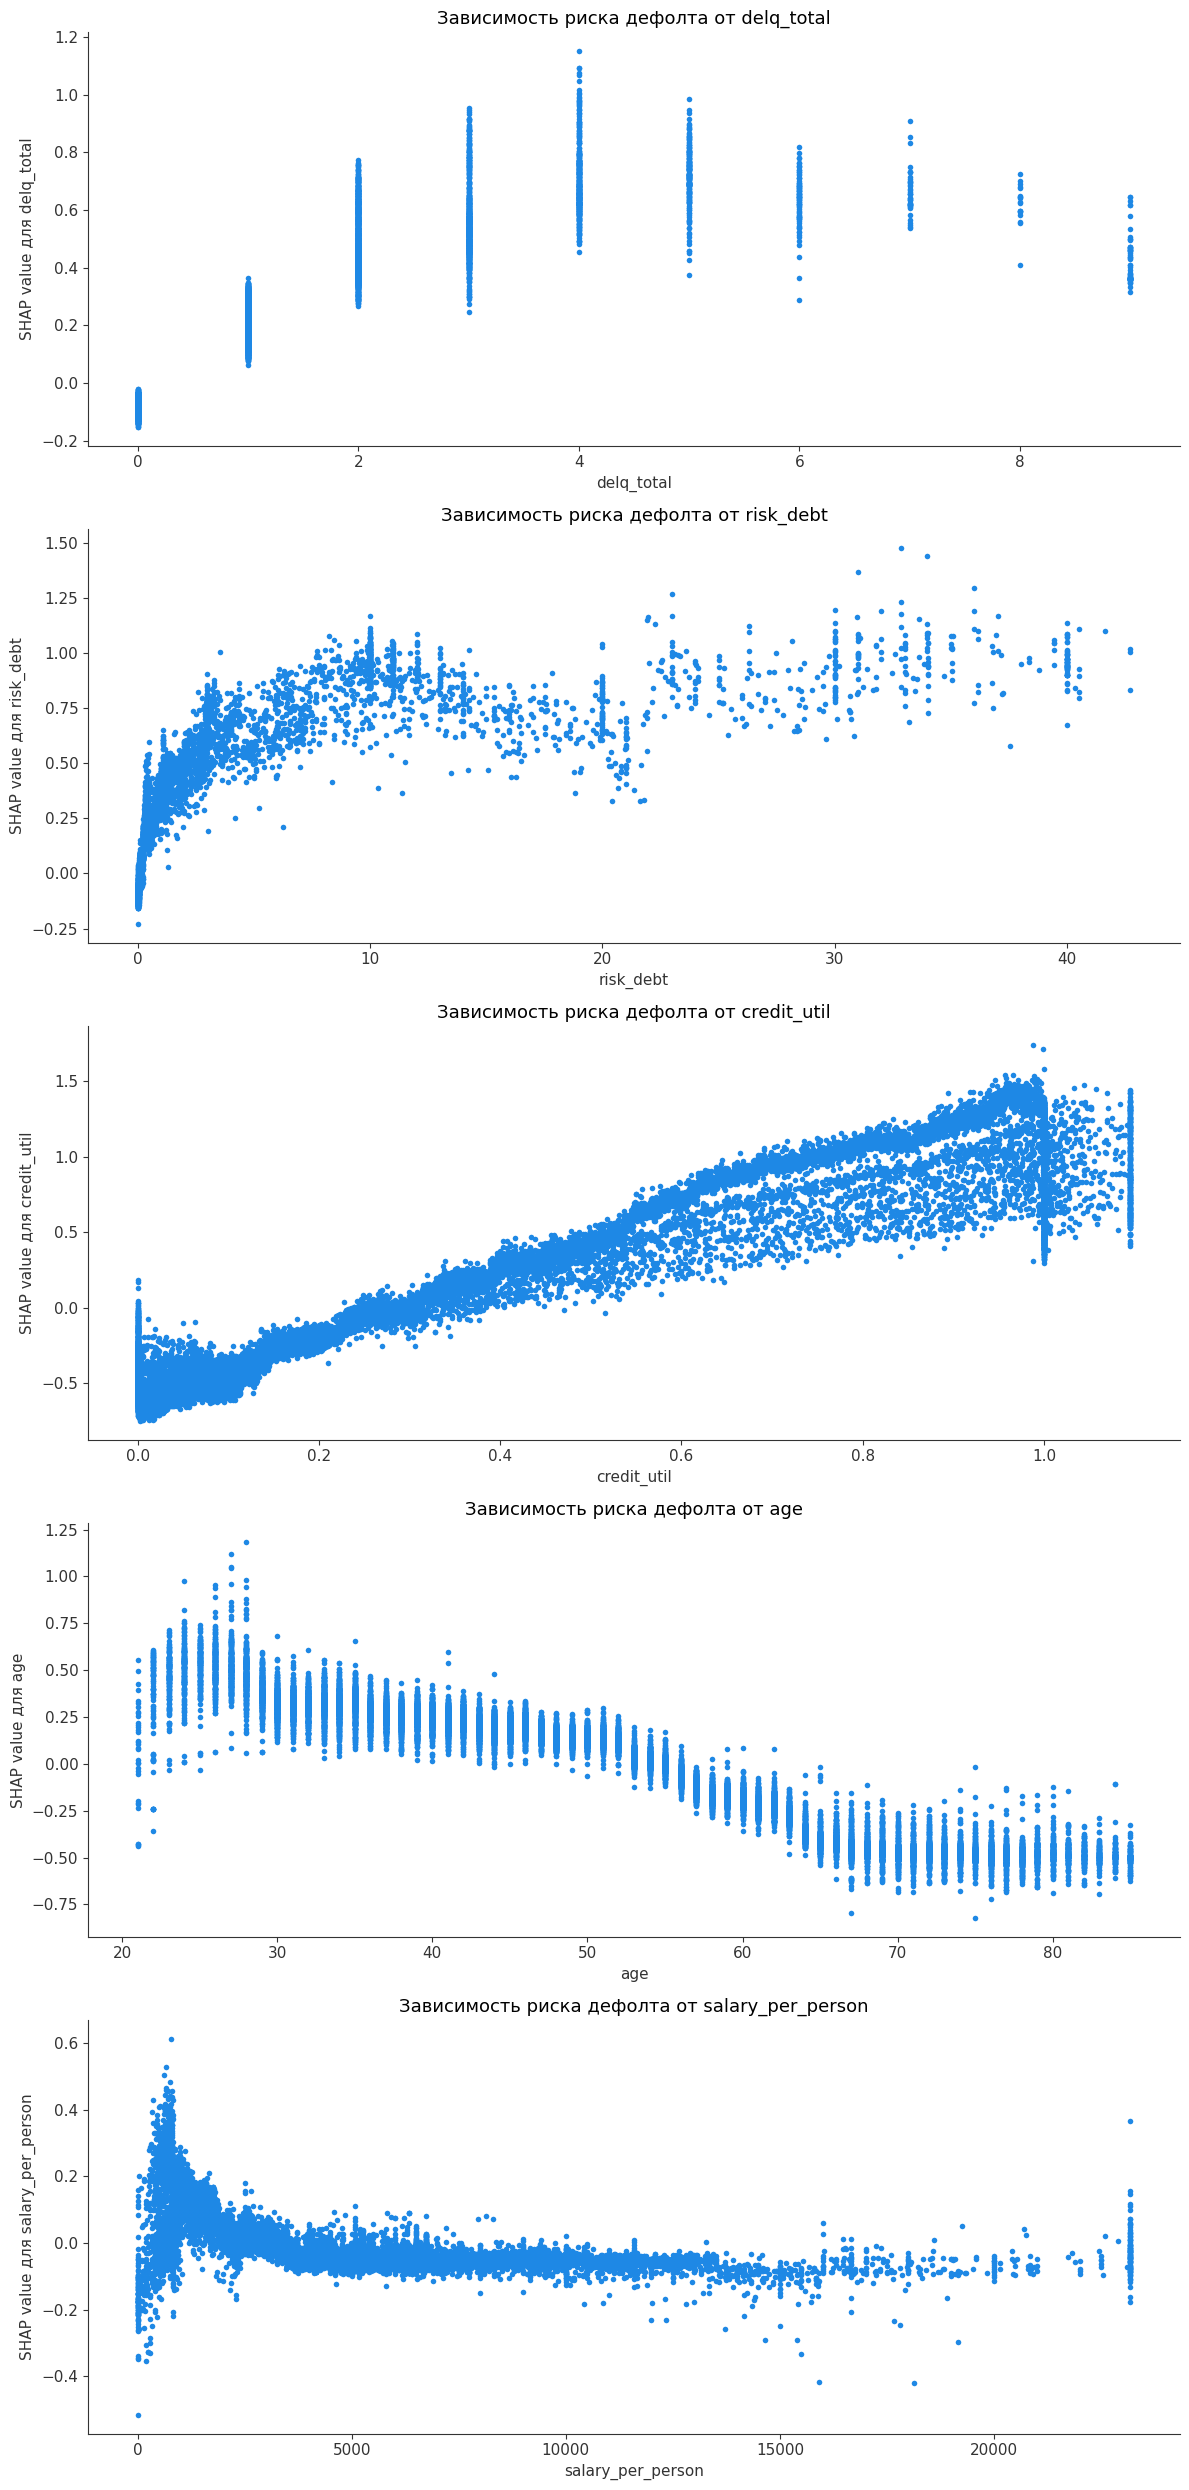

In [31]:
top_features = ['delq_total', 'risk_debt', 'credit_util', 'age', 'salary_per_person']

fig, axes = plt.subplots(len(top_features), 1, figsize=(12, 5 * len(top_features)))

for i, feat in enumerate(top_features):
    ax = axes[i]
    shap.dependence_plot(
        feat, 
        shap_values, 
        X_test, 
        interaction_index=None, 
        ax=ax,
        show=False
    )
    ax.set_title(f'Зависимость риска дефолта от {feat}', fontsize=13)
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel(f'SHAP value для {feat}', fontsize=11)

plt.tight_layout()
plt.show()

### Бизнес выводы

#### 1. Модель готова к внедрению

- **ROC-AUC 0.87** — модель хорошо разделяет надёжных и рисковых заёмщиков
- Отказ от `class_weight='Balanced'` в пользу **Platt Scaling** позволил получить реалистичные PD (Probability of Default)      
     
---

#### 2. Экономический эффект

- При оптимальном пороге модель приносит **на 15% больше прибыли**, чем стратегия «одобряем всех»
- **Один пропущенный дефолт (80 000 ₽) стоит как 4 одобренных хороших кредита (4 × 20 000 ₽)** — поэтому выгоднее перестраховаться и отказать части надёжных клиентов
- Даже с учётом упущенной прибыли от ложных отказов, чистая прибыль **выше**, чем при попытке поймать всех дефолтников

---

#### 3. Портрет рискованного заёмщика (по SHAP-анализу)

| Признак | Значение | Интерпретация |
|:---|:---|:---|
| `delq_total` | ≥ 3 | 3+ просрочек за последние 2 года |
| `risk_debt` | Высокий | Утилизация карт > 70% + есть просрочки |
| `salary_per_person` | Ниже медианы | Низкий доход на члена семьи |
| `age` | < 25 или > 60 | Молодые и пожилые — зона риска |    
  
> **Рекомендация:** таким клиентам предлагать продукты с обеспечением (залог, поручитель) или повышенную ставку вместо полного отказа. Это позволяет **монетизировать риск**, а не просто блокировать его.
  
---

#### 4. Неожиданные выводы

- Клиенты, **не указавшие доход** в анкете, оказались **НАДЁЖНЕЕ** (корреляция с таргетом -0.013)
- Возможная причина: состоятельные люди не хотят раскрывать финансы, но кредиты платят исправно
- **Рекомендация:** не относиться к пропуску дохода как к стоп-фактору, использовать это как слабый позитивный сигнал